# Сессионная работа

## Кластеризация сигналов сцинтилляционного детектора

### Цель работы

Целью работы является автоматическая кластеризация сигналов сцинтилляционного детектора с использованием методов машинного обучения без учителя.

В ходе работы необходимо:

- исследовать структуру данных;
- выполнить анализ данных (EDA);
- провести предобработку;
- разработать новые признаки;
- сравнить несколько алгоритмов кластеризации;
- подобрать оптимальные параметры моделей;
- сформировать итоговое решение для соревнования Kaggle.

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/signal-types-classification/Description.pdf
/kaggle/input/competitions/signal-types-classification/test-dataset.ipynb
/kaggle/input/competitions/signal-types-classification/Run200_Wave_0_1.txt


In [ ]:
# ============================================================
# Импорт библиотек
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import entropy

from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    MinMaxScaler
)

from sklearn.decomposition import PCA

from sklearn.cluster import (
    KMeans,
    Birch,
    AgglomerativeClustering,
    MiniBatchKMeans,
    SpectralClustering
)

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (10,6)

pd.set_option("display.max_columns", None)

print("Библиотеки успешно импортированы.")

Библиотеки успешно импортированы.


## Загрузка данных

На данном этапе производится загрузка исходного набора данных, содержащего сигналы сцинтилляционного детектора.

Каждая строка соответствует одному зарегистрированному сигналу.

Первые четыре столбца содержат служебную информацию, остальные 500 столбцов представляют собой значения амплитуды сигнала.

In [ ]:
# ============================================================
# Загрузка данных
# ============================================================

PATH = "/kaggle/input/competitions/signal-types-classification/Run200_Wave_0_1.txt"

df = pd.read_csv(
    PATH,
    sep=r"\s+",
    header=None
)

print("Размер датасета:", df.shape)

display(df.head())

Размер датасета: (23479, 504)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,14820,14822,14824,14820,14828,14819,14822,14822,14820,14822,14820,14819,14820,14821,14815,14830,14824,14825,14820,14820,14824,14822,14817,14825,14820,14814,14822,14823,14824,14820,14820,14823,14822,14817,14824,14826,14823,14822,14818,14822,14820,14817,14820,14821,14822,14820,14818,14820,14820,14825,14818,14819,14824,14822,14818,14820,14827,14826,14824,14819,14820,14822,14820,14820,14822,14825,14822,14821,14817,14822,14819,14821,14823,14821,14817,14820,14827,14820,14820,14823,14820,14815,14820,14822,14820,14824,14817,14818,14819,14822,14819,14818,14827,14820,14818,14820,14819,14818,14820,14824,14822,14820,14817,14822,14820,14817,14824,14822,14823,14824,14820,14825,14818,14823,14817,14820,14824,14824,14815,14820,14820,14822,14817,14822,14820,14820,14820,14822,14820,14819,14818,14823,14818,14818,14820,14814,14763,14563,14378,14291,14378,14460,14532,14607,14630,14681,14732,14741,14748,14756,14772,14779,14790,14792,14799,14801,14799,14797,14792,14803,14798,14794,14794,14814,14808,14811,14810,14807,14815,14810,14807,14801,14804,14804,14801,14801,14810,14806,14791,14813,14799,14802,14804,14811,14812,14803,14803,14812,14816,14819,14812,14809,14817,14817,14815,14817,14820,14817,14812,14816,14819,14816,14815,14822,14806,14817,14809,14813,14810,14813,14812,14819,14812,14815,14812,14823,14810,14810,14819,14819,14822,14813,14816,14820,14816,14817,14820,14819,14817,14821,14820,14826,14819,14820,14820,14826,14819,14821,14812,14820,14817,14813,14812,14815,14815,14814,14817,14817,14817,14815,14814,14820,14815,14813,14810,14820,14822,14821,14818,14818,14819,14820,14812,14818,14820,14816,14818,14819,14817,14819,14820,14816,14817,14816,14819,14819,14818,14818,14817,14820,14818,14824,14823,14813,14817,14818,14815,14825,14819,14827,14818,14815,14820,14823,14815,14822,14827,14822,14818,14818,14818,14822,14812,14830,14819,14817,14823,14828,14824,14810,14817,14827,14823,14814,14820,14821,14820,14816,14818,14828,14818,14822,14819,14823,14817,14816,14824,14822,14823,14818,14822,14825,14820,14823,14818,1

In [ ]:
# ============================================================
# Переименование столбцов
# ============================================================

columns = [
    "event_id",
    "param_1",
    "param_2",
    "signal_length"
]

columns += [f"sample_{i}" for i in range(500)]

df.columns = columns

print(df.head())

   event_id  param_1  param_2  signal_length  sample_0  sample_1  sample_2  \
0   2890276      357      113            500     14820     14823     14824   
1   4928764      740      359            500     14820     14822     14820   
2   9630204      162      499            500     14820     14820     14822   
3  15798632      841      123            500     14828     14822     14818   
4  20637296      412      348            500     14823     14815     14823   

   sample_3  sample_4  sample_5  sample_6  sample_7  sample_8  sample_9  \
0     14822     14818     14820     14824     14822     14820     14820   
1     14826     14824     14822     14820     14822     14823     14821   
2     14825     14820     14824     14824     14819     14823     14824   
3     14824     14824     14822     14820     14822     14824     14820   
4     14821     14827     14820     14823     14824     14816     14821   

   sample_10  sample_11  sample_12  sample_13  sample_14  sample_15  \
0      14

## Первичный анализ данных

Перед началом обработки необходимо убедиться в корректности структуры датасета:

- определить размеры;
- проверить типы данных;
- проверить наличие пропусков;
- определить количество дубликатов.

In [ ]:
# ============================================================
# Общая информация
# ============================================================

print("="*60)
print("Размер датасета")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("Типы данных")
print("="*60)

display(df.dtypes.value_counts())

print("\n")

print("="*60)
print("Пропуски")
print("="*60)

display(df.isnull().sum().sort_values(ascending=False).head())

print("\n")

print("="*60)
print("Дубликаты")
print("="*60)

print(df.duplicated().sum())

Размер датасета
(23479, 504)


Типы данных


int64    504
Name: count, dtype: int64



Пропуски


event_id         0
param_1          0
param_2          0
signal_length    0
sample_0         0
dtype: int64



Дубликаты
0


In [ ]:
# ============================================================
# Статистика
# ============================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
event_id,23479.0,1.009742e+11,5.715472e+10,2890276.0,5.156311e+10,1.014553e+11,1.502418e+11,2.000107e+11
param_1,23479.0,8.691600e+02,5.729058e+02,0.0,3.730000e+02,8.100000e+02,1.341000e+03,1.998000e+03
param_2,23479.0,3.721917e+02,4.703917e+02,10.0,6.400000e+01,1.720000e+02,4.830000e+02,3.370000e+03
signal_length,23479.0,5.000000e+02,0.000000e+00,500.0,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02
sample_0,23479.0,1.482297e+04,2.805884e+00,14812.0,1.482100e+04,1.482300e+04,1.482400e+04,1.483400e+04
...,...,...,...,...,...,...,...,...
sample_495,23479.0,1.482232e+04,3.232245e+00,14801.0,1.482000e+04,1.482300e+04,1.482400e+04,1.483400e+04
sample_496,23479.0,1.482228e+04,3.268458e+00,14798.0,1.482000e+04,1.482300e+04,1.482400e+04,1.483300e+04
sample_497,23479.0,1.482228e+04,3.251192e+00,14804.0,1.482000e+04,1.482300e+04,1.482400e+04,1.483400e+04
sample_498,23479.0,1.482229e+04,3.253340e+00,14800.0,1.482000e+04,1.482300e+04,1.482400e+04,1.483300e+04


In [ ]:
# ============================================================
# Проверка служебных признаков
# ============================================================

service = df[
    [
        "event_id",
        "param_1",
        "param_2",
        "signal_length"
    ]
]

display(service.describe())

,event_id,param_1,param_2,signal_length
count,2.347900e+04,23479.000000,23479.000000,23479.0
mean,1.009742e+11,869.160015,372.191661,500.0
std,5.715472e+10,572.905756,470.391688,0.0
min,2.890276e+06,0.000000,10.000000,500.0
25%,5.156311e+10,373.000000,64.000000,500.0
50%,1.014553e+11,810.000000,172.000000,500.0
75%,1.502418e+11,1341.000000,483.000000,500.0
max,2.000107e+11,1998.000000,3370.000000,500.0


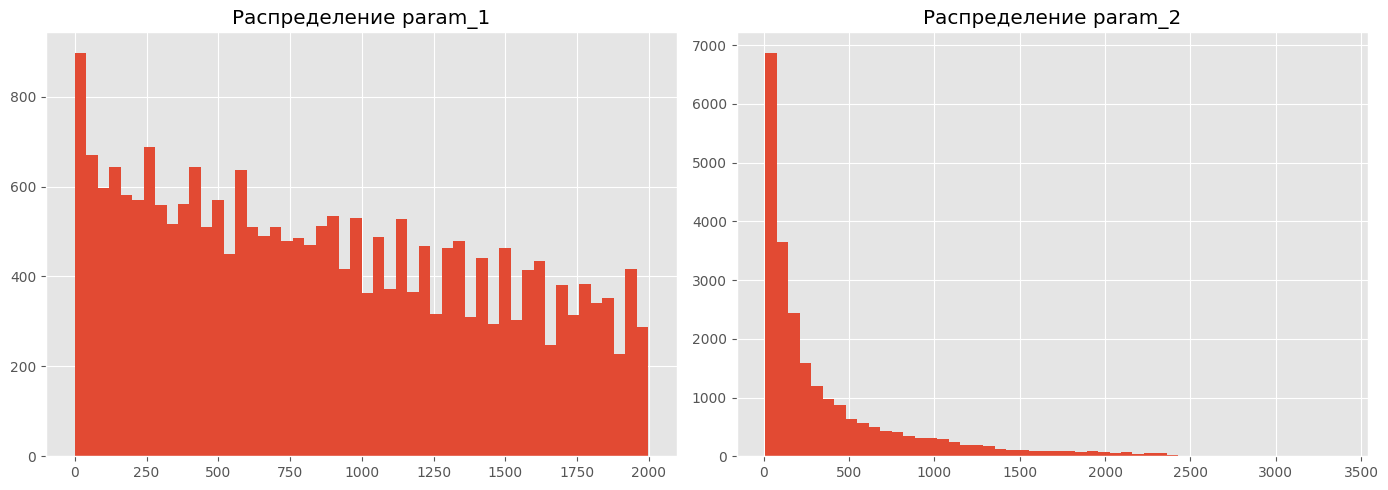

In [ ]:
# ============================================================
# Распределение признаков
# ============================================================

fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].hist(df["param_1"], bins=50)

ax[0].set_title("Распределение param_1")

ax[1].hist(df["param_2"], bins=50)

ax[1].set_title("Распределение param_2")

plt.tight_layout()

plt.show()

# Исследование формы сигналов

Основную информацию о типе частицы содержит форма зарегистрированного сигнала.

Каждый сигнал состоит из 500 последовательных отсчетов амплитуды.

На данном этапе проводится анализ:

- среднего сигнала;
- стандартного отклонения;
- отдельных примеров сигналов;
- распределения амплитуд;
- изменчивости сигнала.

In [ ]:
# ============================================================
# Выделение сигналов
# ============================================================

signal_cols = [f"sample_{i}" for i in range(500)]

signals = df[signal_cols]

print("Размер матрицы сигналов:", signals.shape)

display(signals.head())

Размер матрицы сигналов: (23479, 500)


,sample_0,sample_1,sample_2,sample_3,sample_4,sample_5,sample_6,sample_7,sample_8,sample_9,sample_10,sample_11,sample_12,sample_13,sample_14,sample_15,sample_16,sample_17,sample_18,sample_19,sample_20,sample_21,sample_22,sample_23,sample_24,sample_25,sample_26,sample_27,sample_28,sample_29,sample_30,sample_31,sample_32,sample_33,sample_34,sample_35,sample_36,sample_37,sample_38,sample_39,sample_40,sample_41,sample_42,sample_43,sample_44,sample_45,sample_46,sample_47,sample_48,sample_49,sample_50,sample_51,sample_52,sample_53,sample_54,sample_55,sample_56,sample_57,sample_58,sample_59,sample_60,sample_61,sample_62,sample_63,sample_64,sample_65,sample_66,sample_67,sample_68,sample_69,sample_70,sample_71,sample_72,sample_73,sample_74,sample_75,sample_76,sample_77,sample_78,sample_79,sample_80,sample_81,sample_82,sample_83,sample_84,sample_85,sample_86,sample_87,sample_88,sample_89,sample_90,sample_91,sample_92,sample_93,sample_94,sample_95,sample_96,sample_97,sample_98,sample_99,sample_100,sample_101,sample_102,sample_103,sample_104,sample_105,sample_106,sample_107,sample_108,sample_109,sample_110,sample_111,sample_112,sample_113,sample_114,sample_115,sample_116,sample_117,sample_118,sample_119,sample_120,sample_121,sample_122,sample_123,sample_124,sample_125,sample_126,sample_127,sample_128,sample_129,sample_130,sample_131,sample_132,sample_133,sample_134,sample_135,sample_136,sample_137,sample_138,sample_139,sample_140,sample_141,sample_142,sample_143,sample_144,sample_145,sample_146,sample_147,sample_148,sample_149,sample_150,sample_151,sample_152,sample_153,sample_154,sample_155,sample_156,sample_157,sample_158,sample_159,sample_160,sample_161,sample_162,sample_163,sample_164,sample_165,sample_166,sample_167,sample_168,sample_169,sample_170,sample_171,sample_172,sample_173,sample_174,sample_175,sample_176,sample_177,sample_178,sample_179,sample_180,sample_181,sample_182,sample_183,sample_184,sample_185,sample_186,sample_187,sample_188,sample_189,sample_190,sample_191,sample_192,sample_193,sample_194,sample_195,sample_196,sample_197,sample_198,sample_199,sample_200,sample_201,sample_202,sample_203,sample_204,sample_205,sample_206,sample_207,sample_208,sample_209,sample_210,sample_211,sample_212,sample_213,sample_214,sample_215,sample_216,sample_217,sample_218,sample_219,sample_220,sample_221,sample_222,sample_223,sample_224,sample_225,sample_226,sample_227,sample_228,sample_229,sample_230,sample_231,sample_232,sample_233,sample_234,sample_235,sample_236,sample_237,sample_238,sample_239,sample_240,sample_241,sample_242,sample_243,sample_244,sample_245,sample_246,sample_247,sample_248,sample_249,sample_250,sample_251,sample_252,sample_253,sample_254,sample_255,sample_256,sample_257,sample_258,sample_259,sample_260,sample_261,sample_262,sample_263,sample_264,sample_265,sample_266,sample_267,sample_268,sample_269,sample_270,sample_271,sample_272,sample_273,sample_274,sample_275,sample_276,sample_277,sample_278,sample_279,sample_280,sample_281,sample_282,sample_283,sample_284,sample_285,sample_286,sample_287,sample_288,sample_289,sample_290,sample_291,sample_292,sample_293,sample_294,sample_295,sample_296,sample_297,sample_298,sample_299,sample_300,sample_301,sample_302,sample_303,sample_304,sample_305,sample_306,sample_307,sample_308,sample_309,sample_310,sample_311,sample_312,sample_313,sample_314,sample_315,sample_316,sample_317,sample_318,sample_319,sample_320,sample_321,sample_322,sample_323,sample_324,sample_325,sample_326,sample_327,sample_328,sample_329,sample_330,sample_331,sample_332,sample_333,sample_334,sample_335,sample_336,sample_337,sample_338,sample_339,sample_340,sample_341,sample_342,sample_343,sample_344,sample_345,sample_346,sample_347,sample_348,sample_349,sample_350,sample_351,sample_352,sample_353,sample_354,sample_355,sample_356,sample_357,sample_358,sample_359,sample_360,sample_361,sample_362,sample_363,sample_364,sample_365,sample_366,sample_367,sample_368,sample_369,sample_370,sample_371,sample_372,sample

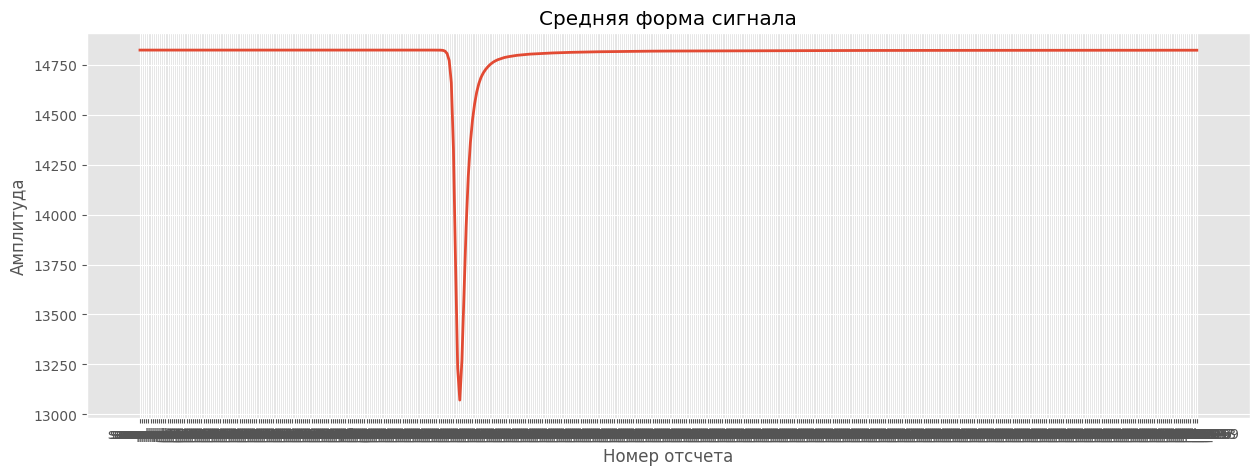

In [ ]:
# ============================================================
# Средний сигнал
# ============================================================

mean_signal = signals.mean(axis=0)

plt.figure(figsize=(15,5))

plt.plot(mean_signal, linewidth=2)

plt.title("Средняя форма сигнала")

plt.xlabel("Номер отсчета")

plt.ylabel("Амплитуда")

plt.grid(True)

plt.show()

### Вывод

Средний сигнал имеет выраженный импульс.

Максимальные изменения наблюдаются только в небольшой области сигнала.

Остальная часть сигнала практически постоянна.

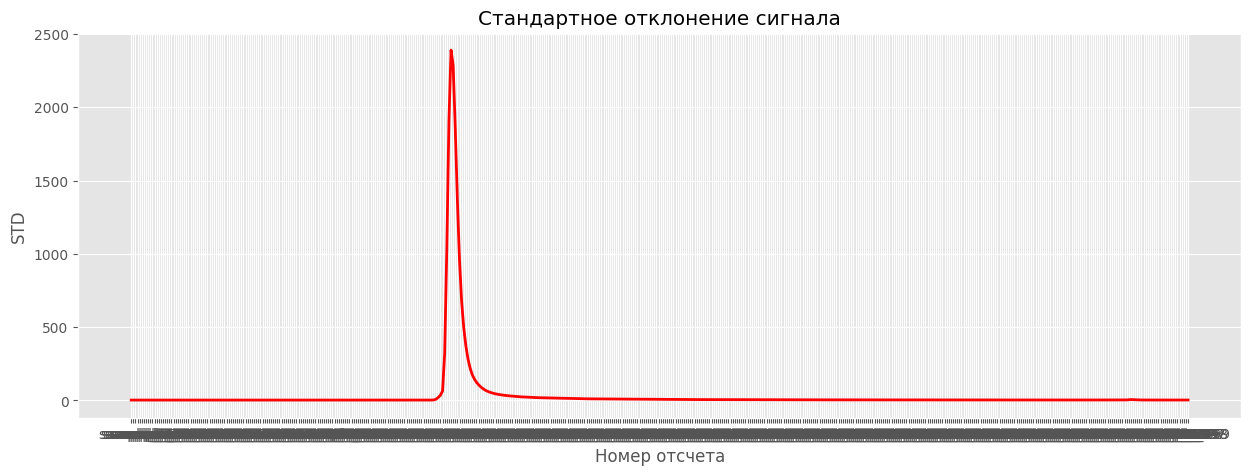

In [ ]:
# ============================================================
# Стандартное отклонение
# ============================================================

std_signal = signals.std(axis=0)

plt.figure(figsize=(15,5))

plt.plot(
    std_signal,
    color="red",
    linewidth=2
)

plt.title("Стандартное отклонение сигнала")

plt.xlabel("Номер отсчета")

plt.ylabel("STD")

plt.grid(True)

plt.show()

### Вывод

Наибольшая изменчивость наблюдается непосредственно в области импульса.

Это свидетельствует о том, что именно эта часть сигнала содержит основную информацию,
необходимую для разделения различных типов частиц.

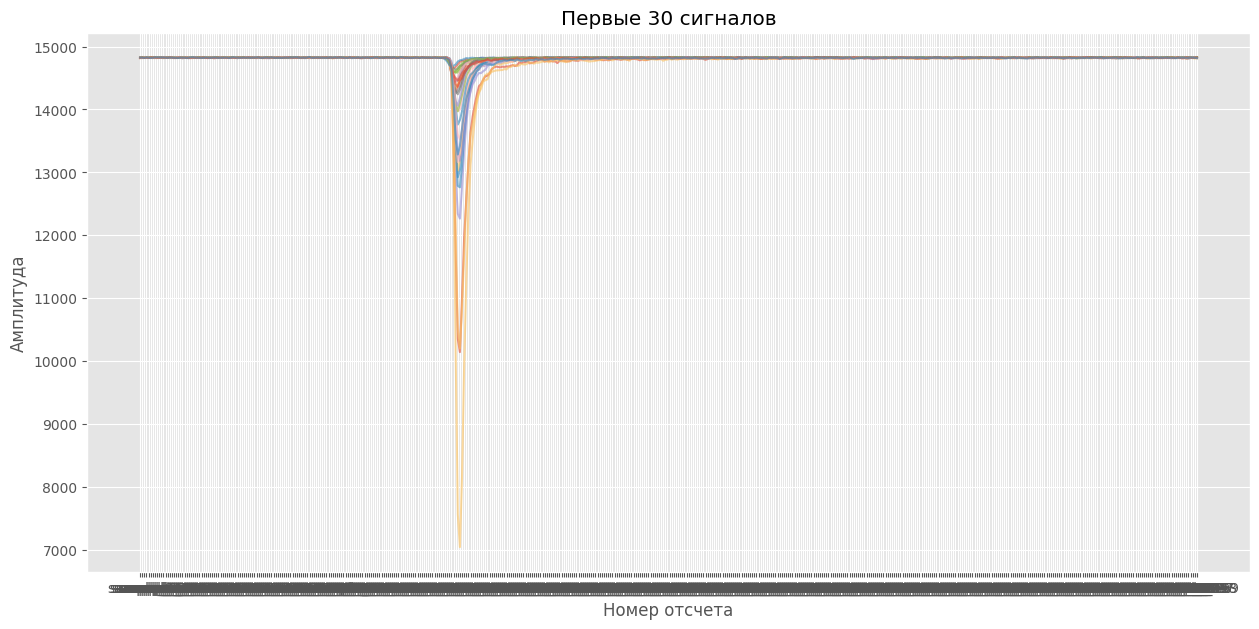

In [ ]:
# ============================================================
# Первые 30 сигналов
# ============================================================

plt.figure(figsize=(15,7))

for i in range(30):

    plt.plot(
        signals.iloc[i],
        alpha=0.6
    )

plt.title("Первые 30 сигналов")

plt.xlabel("Номер отсчета")

plt.ylabel("Амплитуда")

plt.grid(True)

plt.show()

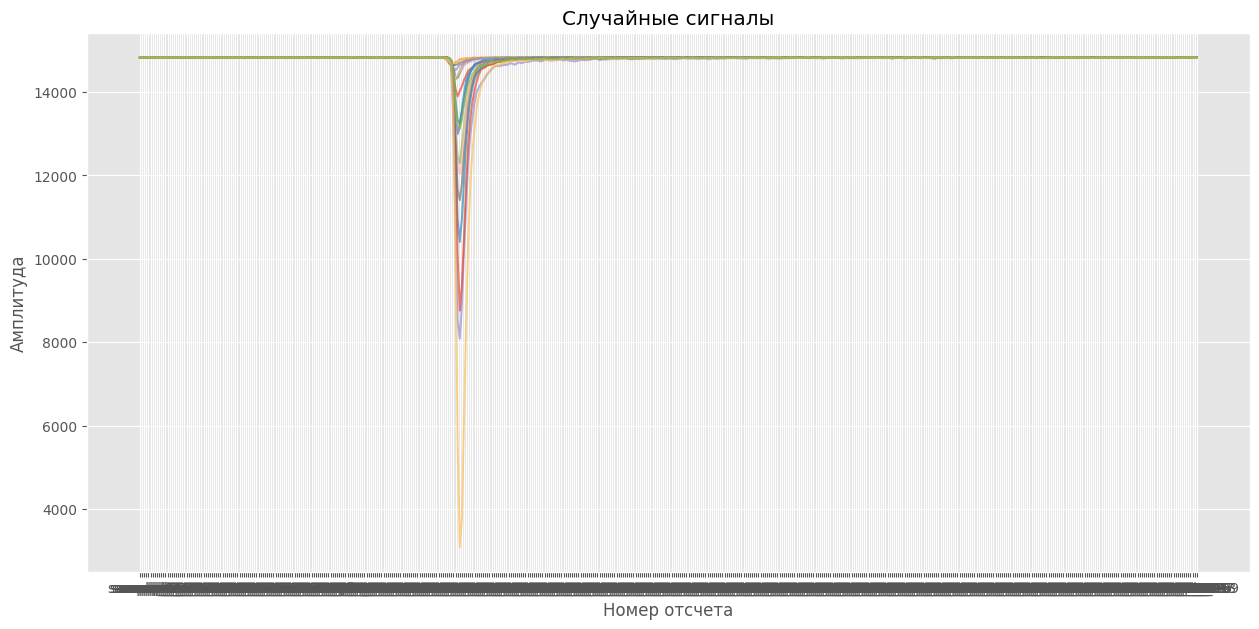

In [ ]:
# ============================================================
# Случайные сигналы
# ============================================================

np.random.seed(42)

plt.figure(figsize=(15,7))

for idx in np.random.choice(len(signals),20):

    plt.plot(
        signals.iloc[idx],
        alpha=0.7
    )

plt.title("Случайные сигналы")

plt.xlabel("Номер отсчета")

plt.ylabel("Амплитуда")

plt.grid(True)

plt.show()

### Вывод

Все сигналы имеют одинаковую общую структуру.

Основные различия наблюдаются:

- глубина импульса;
- ширина импульса;
- скорость восстановления сигнала.

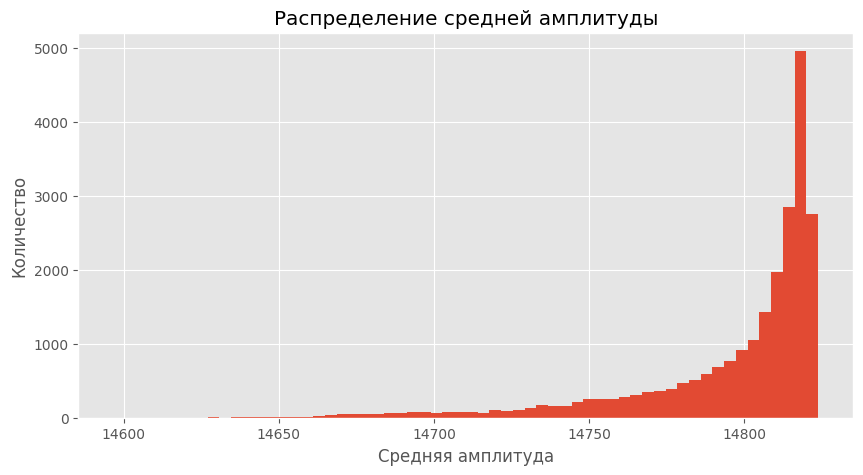

In [ ]:
# ============================================================
# Средняя амплитуда
# ============================================================

signal_mean = signals.mean(axis=1)

plt.figure(figsize=(10,5))

plt.hist(
    signal_mean,
    bins=60
)

plt.title("Распределение средней амплитуды")

plt.xlabel("Средняя амплитуда")

plt.ylabel("Количество")

plt.show()

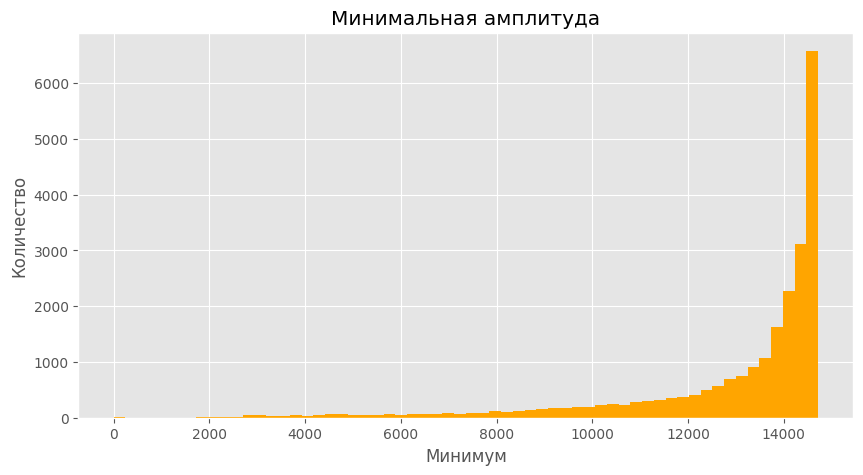

In [ ]:
# ============================================================
# Минимальная амплитуда
# ============================================================

signal_min = signals.min(axis=1)

plt.figure(figsize=(10,5))

plt.hist(
    signal_min,
    bins=60,
    color="orange"
)

plt.title("Минимальная амплитуда")

plt.xlabel("Минимум")

plt.ylabel("Количество")

plt.show()

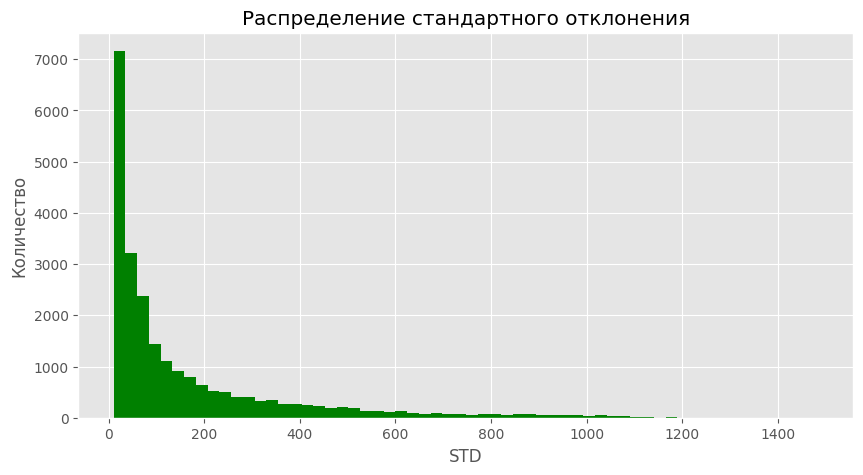

In [ ]:
# ============================================================
# Стандартное отклонение сигнала
# ============================================================

signal_std = signals.std(axis=1)

plt.figure(figsize=(10,5))

plt.hist(
    signal_std,
    bins=60,
    color="green"
)

plt.title("Распределение стандартного отклонения")

plt.xlabel("STD")

plt.ylabel("Количество")

plt.show()

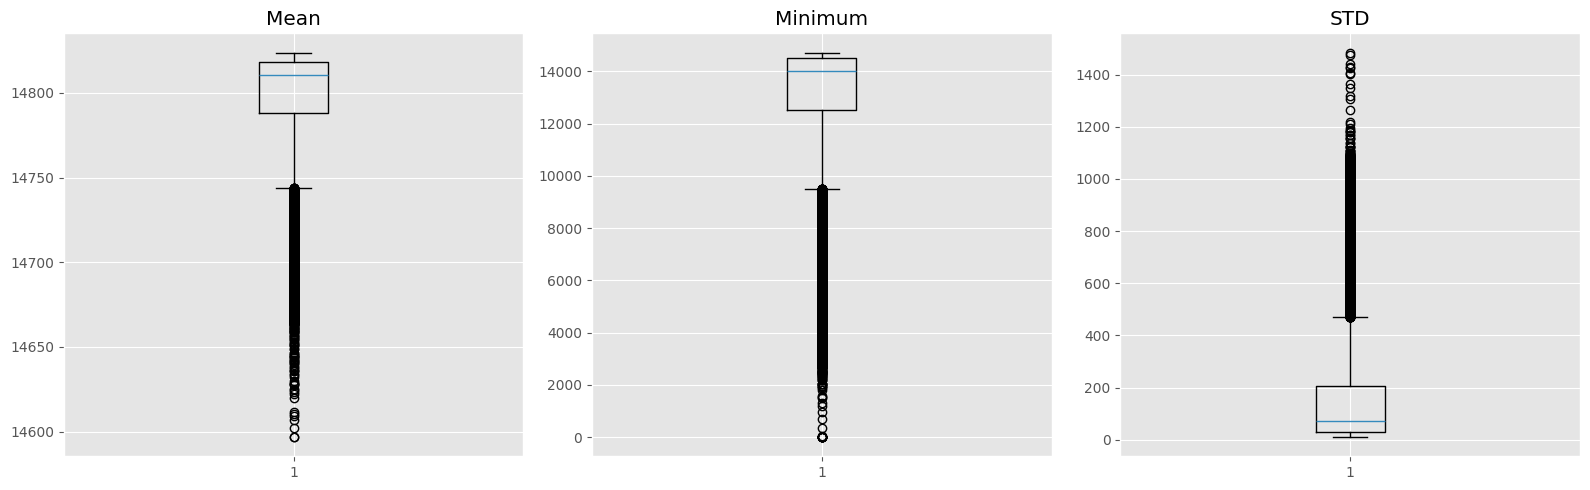

In [ ]:
# ============================================================
# Boxplot признаков
# ============================================================

fig, ax = plt.subplots(1,3, figsize=(16,5))

ax[0].boxplot(signal_mean)

ax[0].set_title("Mean")

ax[1].boxplot(signal_min)

ax[1].set_title("Minimum")

ax[2].boxplot(signal_std)

ax[2].set_title("STD")

plt.tight_layout()

plt.show()

### Вывод

Анализ распределений показывает наличие сигналов с существенно отличающимися характеристиками.

Такие сигналы могут соответствовать:

- редким событиям;
- шумовым измерениям;
- выбросам;
- третьему кластеру, описанному в условии соревнования.

# Feature Engineering

Для повышения качества кластеризации из исходных сигналов извлекаются дополнительные признаки.

В качестве признаков используются:

- статистические характеристики;
- энергетические характеристики;
- характеристики формы импульса;
- временные характеристики;
- интегральные показатели.

Полученные признаки позволяют значительно сократить размерность задачи и улучшить разделимость кластеров.

In [ ]:
# ============================================================
# Feature Engineering
# ============================================================

from scipy.stats import skew, kurtosis
from scipy.stats import entropy

features = pd.DataFrame(index=df.index)

# ----------------------------------------------------
# Основные статистики
# ----------------------------------------------------

features["mean"] = signals.mean(axis=1)
features["median"] = signals.median(axis=1)

features["min"] = signals.min(axis=1)
features["max"] = signals.max(axis=1)

features["std"] = signals.std(axis=1)
features["var"] = signals.var(axis=1)

features["q25"] = signals.quantile(0.25, axis=1)
features["q75"] = signals.quantile(0.75, axis=1)

features["iqr"] = features["q75"] - features["q25"]

features["range"] = (
    features["max"] -
    features["min"]
)

print(features.shape)

display(features.head())

(23479, 10)


,mean,median,min,max,std,var,q25,q75,iqr,range
0,14811.902,14820.0,14291,14830,46.208472,2135.222842,14817.0,14822.0,5.0,539
1,14797.774,14820.0,12921,14828,163.272112,26657.782489,14818.0,14823.0,5.0,1907
2,14788.010,14820.0,12264,14830,225.369832,50791.561022,14818.0,14822.0,4.0,2566
3,14813.444,14821.0,14258,14831,50.120565,2512.071006,14819.0,14824.0,5.0,573
4,14798.218,14820.0,13028,14828,156.545416,24506.467411,14818.0,14823.0,5.0,1800


In [ ]:
# ============================================================
# Амплитудные характеристики
# ============================================================

features["depth"] = (
    features["mean"] -
    features["min"]
)

features["peak_height"] = (
    features["max"] -
    features["mean"]
)

features["peak_to_peak"] = (
    features["max"] -
    features["min"]
)

features["argmin"] = (
    signals.idxmin(axis=1)
    .str.replace("sample_","")
    .astype(int)
)

features["argmax"] = (
    signals.idxmax(axis=1)
    .str.replace("sample_","")
    .astype(int)
)

In [ ]:
# ============================================================
# Энергия сигнала
# ============================================================

signal_array = signals.to_numpy()

features["energy"] = np.sum(signal_array**2, axis=1)

features["rms"] = np.sqrt(
    np.mean(signal_array**2, axis=1)
)

features["abs_sum"] = np.sum(
    np.abs(signal_array),
    axis=1
)

features["signal_sum"] = np.sum(
    signal_array,
    axis=1
)

features["signal_mean_abs"] = np.mean(
    np.abs(signal_array),
    axis=1
)

In [ ]:
# ============================================================
# Интегралы сигнала
# ============================================================

baseline = np.median(
    signal_array[:, :100],
    axis=1
)

corrected = baseline[:, None] - signal_array

corrected[corrected < 0] = 0

features["pulse_area"] = corrected.sum(axis=1)

features["pulse_max"] = corrected.max(axis=1)

features["pulse_mean"] = corrected.mean(axis=1)

features["pulse_std"] = corrected.std(axis=1)

features["pulse_energy"] = (
    corrected**2
).sum(axis=1)

In [ ]:
# ============================================================
# Pulse Shape Discrimination
# ============================================================

head = corrected[:, 130:170]

tail = corrected[:, 170:260]

features["head_integral"] = head.sum(axis=1)

features["tail_integral"] = tail.sum(axis=1)

features["tail_ratio"] = (
    features["tail_integral"] /
    (
        features["head_integral"] + 1e-8
    )
)

features["tail_fraction"] = (
    features["tail_integral"] /
    (
        features["pulse_area"] + 1e-8
    )
)

In [ ]:
# ============================================================
# Характеристики формы
# ============================================================

features["skew"] = np.apply_along_axis(
    skew,
    1,
    signal_array
)

features["kurtosis"] = np.apply_along_axis(
    kurtosis,
    1,
    signal_array
)

features["entropy"] = np.apply_along_axis(
    lambda x: entropy(
        np.abs(x)+1
    ),
    1,
    signal_array
)

In [ ]:
# ============================================================
# Производные сигнала
# ============================================================

diff = np.diff(
    signal_array,
    axis=1
)

features["diff_mean"] = diff.mean(axis=1)

features["diff_std"] = diff.std(axis=1)

features["diff_max"] = diff.max(axis=1)

features["diff_min"] = diff.min(axis=1)

features["diff_energy"] = (
    diff**2
).sum(axis=1)

In [ ]:
# ============================================================
# Служебные признаки
# ============================================================

features["param_1"] = df["param_1"]

features["param_2"] = df["param_2"]

print("="*60)

print("Размер новой таблицы признаков")

print(features.shape)

display(features.head())

display(features.describe())

Размер новой таблицы признаков
(23479, 39)


,mean,median,min,max,std,var,q25,q75,iqr,range,depth,peak_height,peak_to_peak,argmin,argmax,energy,rms,abs_sum,signal_sum,signal_mean_abs,pulse_area,pulse_max,pulse_mean,pulse_std,pulse_energy,head_integral,tail_integral,tail_ratio,tail_fraction,skew,kurtosis,entropy,diff_mean,diff_std,diff_max,diff_min,diff_energy,param_1,param_2
0,14811.902,14820.0,14291,14830,46.208472,2135.222842,14817.0,14822.0,5.0,539,520.902,18.098,539,149,25,109697285905,14811.973934,7405951,7405951,14811.902,4767.0,529.5,9.534,45.936269,1100519.00,3530.0,703.5,0.199292,0.147577,-8.208985,73.233273,6.214603,-0.002004,15.980261,87,-200,127429,357,113
1,14797.774,14820.0,12921,14828,163.272112,26657.782489,14818.0,14823.0,5.0,1907,1876.774,30.226,1907,150,26,109500359911,14798.672907,7398887,7398887,14797.774,12836.0,1902.0,25.672,163.035139,13619754.00,11369.0,721.0,0.063418,0.056170,-8.936672,84.934025,6.214545,0.000000,55.682430,364,-745,1547166,740,359
2,14788.010,14820.0,12264,14830,225.369832,50791.561022,14818.0,14822.0,4.0,2566,2524.010,41.990,2566,151,338,109367964869,14789.723788,7394005,7394005,14788.010,17290.0,2558.0,34.580,225.050242,25921694.00,15901.0,743.0,0.046727,0.042973,-8.869747,83.454824,6.214487,0.002004,73.857999,544,-946,2722047,162,499
3,14813.444,14821.0,14258,14831,50.120565,2512.071006,14819.0,14824.0,5.0,573,555.444,17.556,573,149,320,109720315094,14813.528620,7406722,7406722,14813.444,5090.0,565.0,10.180,49.925300,1298084.00,3807.0,684.0,0.179669,0.134381,-8.412439,76.386935,6.214602,-0.012024,16.835877,119,-203,141440,841,123
4,14798.218,14820.0,13028,14828,156.545416,24506.467411,14818.0,14823.0,5.0,1800,1770.218,29.782,1800,150,36,109505856715,14799.044342,7399109,7399109,14798.218,12035.5,1793.5,24.071,156.260806,12498426.25,10973.0,559.0,0.050943,0.046446,-8.862719,83.048625,6.214550,0.004008,53.242554,377,-708,1414550,412,348


,mean,median,min,max,std,var,q25,q75,iqr,range,depth,peak_height,peak_to_peak,argmin,argmax,energy,rms,abs_sum,signal_sum,signal_mean_abs,pulse_area,pulse_max,pulse_mean,pulse_std,pulse_energy,head_integral,tail_integral,tail_ratio,tail_fraction,skew,kurtosis,entropy,diff_mean,diff_std,diff_max,diff_min,diff_energy,param_1,param_2
count,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,2.347900e+04,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,2.347900e+04,23479.000000,2.347900e+04,2.347900e+04,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,2.347900e+04,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.00000,2.347900e+04,23479.000000,23479.000000
mean,14796.683724,14821.214298,12987.861791,14830.711359,161.693850,6.981302e+04,14817.377433,14823.714607,6.337174,1842.849568,1808.821932,34.027636,1842.849568,149.628604,198.072874,1.095063e+11,14799.048468,7.398342e+06,7.398342e+06,14796.683724,13535.616785,1835.174177,27.071234,161.364630,3.570087e+07,11644.027003,1139.191767,0.130718,0.097125,-8.422171,76.998712,6.214417,-0.001380,54.198704,390.937050,-699.11078,3.889419e+06,869.160015,372.191661
std,32.209844,1.776663,2389.308983,1.458499,208.973628,1.748660e+05,4.195834,1.073254,3.489266,2389.075855,2357.422778,31.964362,2389.075855,2.489996,165.293308,3.977266e+08,26.916829,1.610492e+04,1.610492e+04,32.209844,16029.064089,2389.299361,32.058128,208.816938,8.928823e+07,14653.287040,1285.197867,0.066457,0.041399,0.591180,9.725045,0.000528,0.008356,69.693144,503.974038,913.25961,9.747647e+06,572.905756,470.391688
min,14596.798000,14809.000000,0.000000,14827.000000,10.231617,1.046860e+02,14787.000000,14818.000000,2.250000,113.000000,101.578000,7.114000,113.000000,145.000000,0.000000,1.076174e+11,14670.883540,7.298399e+06,7.298399e+06,14596.798000,948.000000,104.000000,1.896000,9.891107,5.100200e+04,638.000000,40.000000,0.020568,0.018268,-12.080568,41.386763,6.205523,-0.050100,4.894273,17.000000,-7082.00000,1.195300e+04,0.000000,10.000000
25%,14788.297000,14820.000000,12508.000000,14830.000000,27.740063,7.695111e+02,14816.750000,14823.000000,4.000000,316.000000,303.353000,13.016000,316.000000,149.000000,50.000000,1.093677e+11,14789.702666,7.394148e+06,7.394148e+06,14788.297000,2909.000000,308.000000,5.818000,27.482783,3.938485e+05,2098.000000,269.000000,0.059835,0.052360,-8.946372,70.036278,6.214509,-0.006012,10.073027,73.000000,-877.00000,5.063150e+04,373.000000,64.000000
50%,14810.496000,14822.000000,14010.000000,14831.000000,72.155612,5.206432e+03,14819.000000,14824.000000,5.000000,820.000000,799.318000,20.438000,820.000000,150.000000,123.000000,1.096780e+11,14810.673169,7.405248e+06,7.405248e+06,14810.496000,6646.000000,813.000000,13.292000,71.905316,2.675824e+06,5367.000000,614.000000,0.138913,0.105416,-8.477376,77.585866,6.214596,-0.002004,24.040539,176.000000,-309.00000,2.883960e+05,810.000000,172.000000
75%,14818.034000,14823.000000,14515.000000,14832.000000,204.672726,4.189093e+04,14820.000000,14824.000000,7.000000,2322.500000,2280.280000,42.296000,2322.500000,151.000000,360.000000,1.097875e+11,14818.063996,7.409017e+06,7.409017e+06,14818.034000,17634.000000,2315.000000,35.268000,204.355293,2.154300e+07,14941.000000,1551.000000,0.181626,0.134323,-8.016792,85.211428,6.214606,0.004008,67.503165,486.000000,-120.00000,2.273782e+06,1341.000000,483.000000
max,14823.788000,14826.000000,14719.000000,14838.000000,1484.918725,2.204984e+06,14824.000000,14828.000000,33.000000,14833.000000,14622.058000,235.202000,14833.000000,472.000000,499.000000,1.098724e+11,14823.792367,7.411894e+06,7.411894e+06,14823.788000,113304.000000,14825.000000,226.608000,1483.370598,1.125870e+09,105475.000000,9392.000000,0.402361,0.206725,-6.107195,161.934853,6.214608,0.028056,480.217006,4112.000000,-30.00000,1.150736e+08,1998.000000,3370.000000


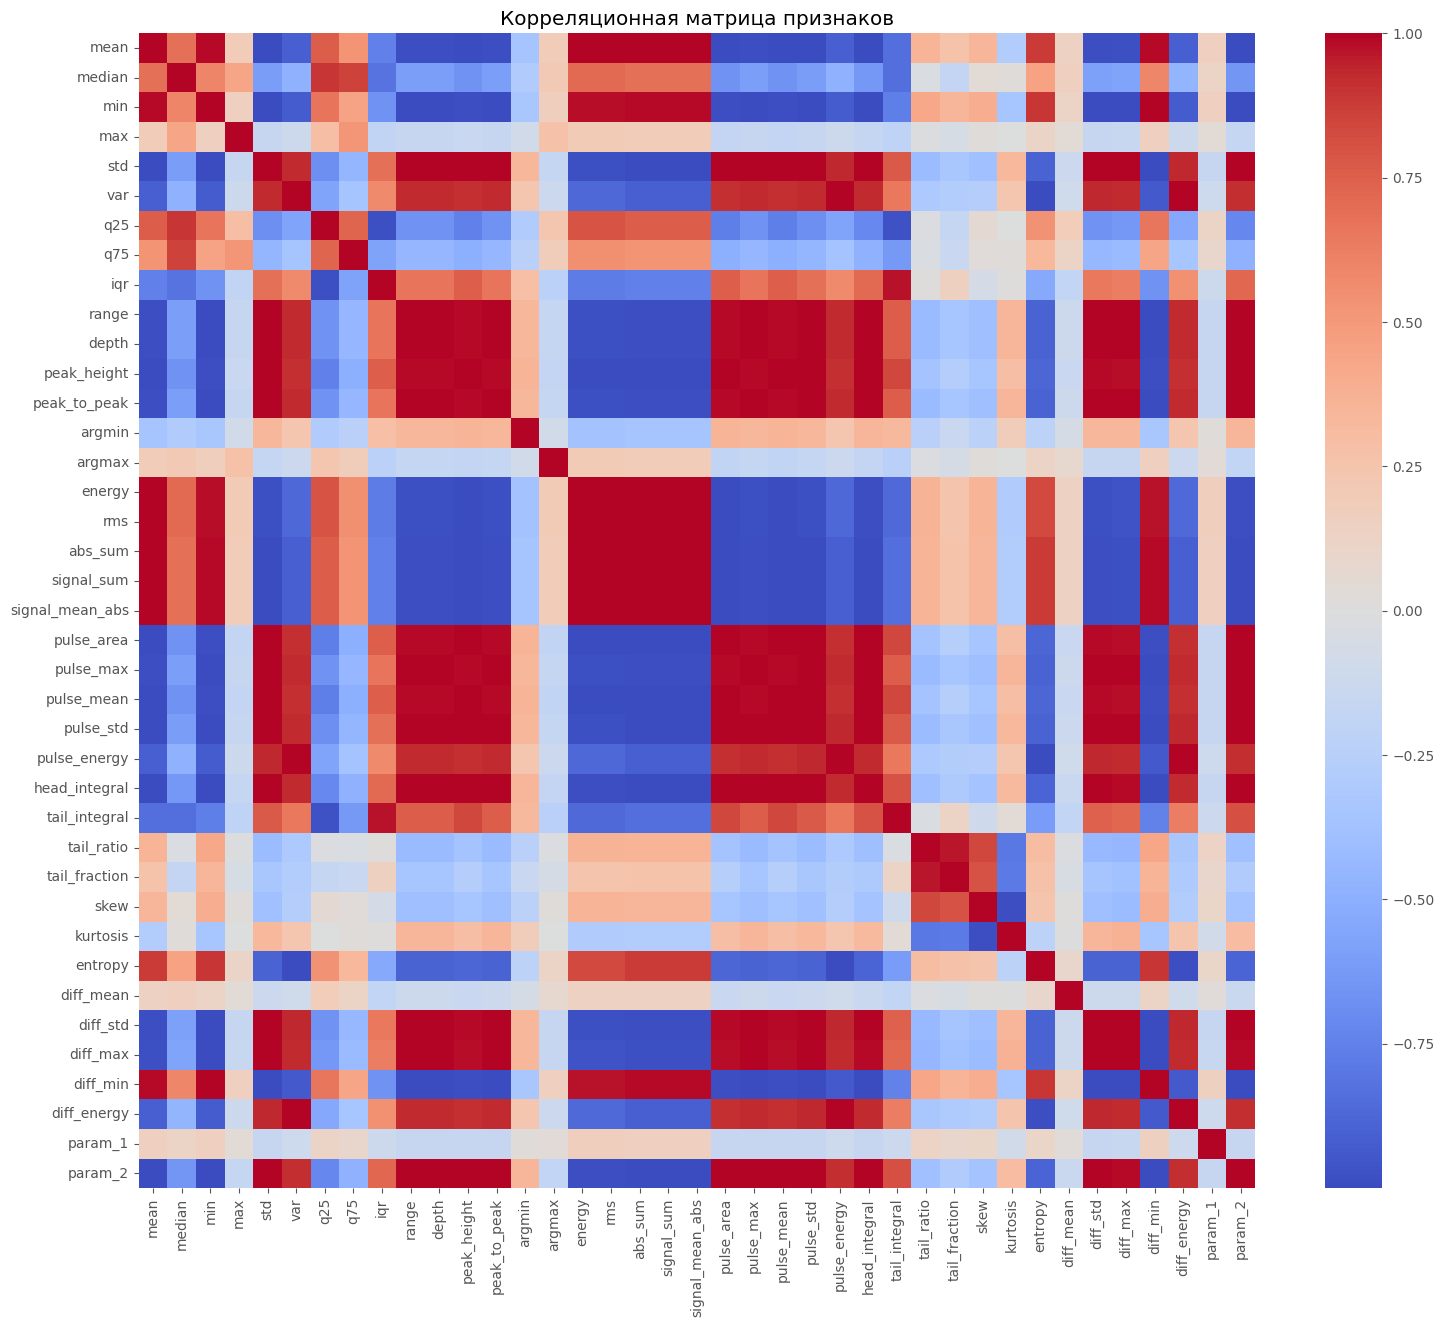

In [ ]:
# ============================================================
# Корреляция
# ============================================================

plt.figure(figsize=(18,15))

corr = features.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Корреляционная матрица признаков")

plt.show()

# Подготовка данных

Перед обучением моделей выполняется:

- удаление константных признаков;
- удаление сильно коррелирующих признаков;
- масштабирование данных.

In [ ]:
# ============================================================
# Удаление константных признаков
# ============================================================

from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)

X = selector.fit_transform(features)

selected_columns = features.columns[selector.get_support()]

X = pd.DataFrame(
    X,
    columns=selected_columns
)

print("После удаления констант:", X.shape)

После удаления констант: (23479, 39)


In [ ]:
# ============================================================
# Удаление коррелирующих признаков
# ============================================================

corr = X.corr().abs()

upper = corr.where(
    np.triu(np.ones(corr.shape),k=1).astype(bool)
)

drop_columns = [
    col
    for col in upper.columns
    if any(upper[col] > 0.98)
]

print("Удаляем признаков:", len(drop_columns))

X = X.drop(columns=drop_columns)

print("Итоговая размерность:", X.shape)

Удаляем признаков: 24
Итоговая размерность: (23479, 15)


In [ ]:
# ============================================================
# Масштабирование
# ============================================================

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(23479, 15)


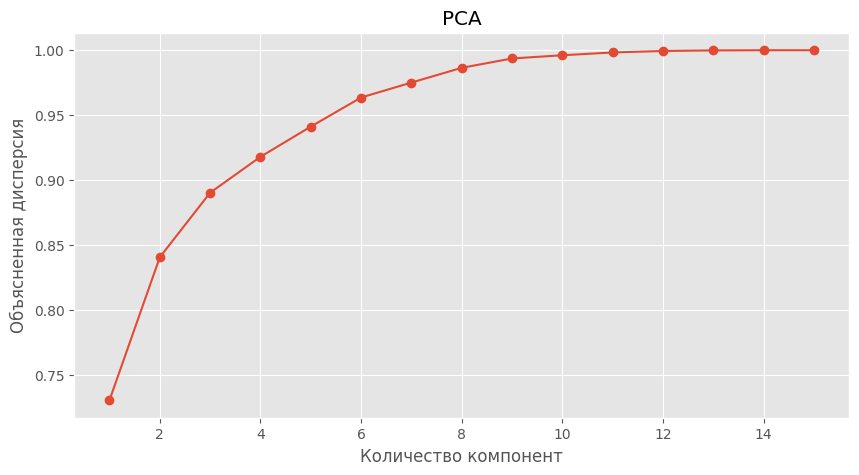

[0.73074559 0.84076415 0.89039352 0.91801285 0.94123432 0.96362142
 0.97513812 0.98646519 0.99365917 0.99613294 0.99827927 0.99941237
 0.99985101 1.         1.        ]


In [ ]:
# ============================================================
# PCA
# ============================================================

from sklearn.decomposition import PCA

pca = PCA()

pca.fit(X_scaled)

variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(10,5))

plt.plot(
    range(1,len(variance)+1),
    variance,
    marker="o"
)

plt.grid(True)

plt.xlabel("Количество компонент")

plt.ylabel("Объясненная дисперсия")

plt.title("PCA")

plt.show()

print(variance)

In [ ]:
# ============================================================
# PCA 95%
# ============================================================

pca = PCA(
    n_components=0.95,
    random_state=42
)

X_pca = pca.fit_transform(
    X_scaled
)

print("Размер после PCA")

print(X_pca.shape)

Размер после PCA
(23479, 6)


In [ ]:
# ============================================================
# Все модели
# ============================================================

models = {

    "KMeans":
        KMeans(
            n_clusters=3,
            random_state=42,
            n_init=50
        ),

    "MiniBatch":
        MiniBatchKMeans(
            n_clusters=3,
            random_state=42,
            batch_size=512,
            n_init=50
        ),

    "Birch":
        Birch(
            n_clusters=3
        ),

    "Agglomerative":
        AgglomerativeClustering(
            n_clusters=3,
            linkage="ward"
        ),

    "Gaussian":
        GaussianMixture(
            n_components=3,
            random_state=42
        ),

    "Spectral":
        SpectralClustering(
            n_clusters=3,
            affinity="nearest_neighbors",
            random_state=42
        )

}

In [ ]:
# ============================================================
# Сравнение моделей
# ============================================================

results = []

labels_dict = {}

for name, model in models.items():

    print("="*60)

    print(name)

    if name == "Gaussian":

        labels = model.fit_predict(X_pca)

    else:

        labels = model.fit_predict(X_pca)

    labels_dict[name] = labels

    sil = silhouette_score(
        X_pca,
        labels
    )

    ch = calinski_harabasz_score(
        X_pca,
        labels
    )

    db = davies_bouldin_score(
        X_pca,
        labels
    )

    results.append([
        name,
        sil,
        ch,
        db
    ])

results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Silhouette",
        "Calinski",
        "Davies"
    ]
)

results = results.sort_values(
    "Silhouette",
    ascending=False
)

display(results)

KMeans
MiniBatch
Birch
Agglomerative
Gaussian
Spectral


,Model,Silhouette,Calinski,Davies
2,Birch,0.757173,15673.280965,0.384659
0,KMeans,0.541239,24716.273667,0.846275
1,MiniBatch,0.514773,24582.301938,0.878678
3,Agglomerative,0.509730,23779.830724,0.891774
5,Spectral,0.418317,14125.476815,0.978167
4,Gaussian,0.156354,7381.093498,1.539652


Лучшая модель: Birch


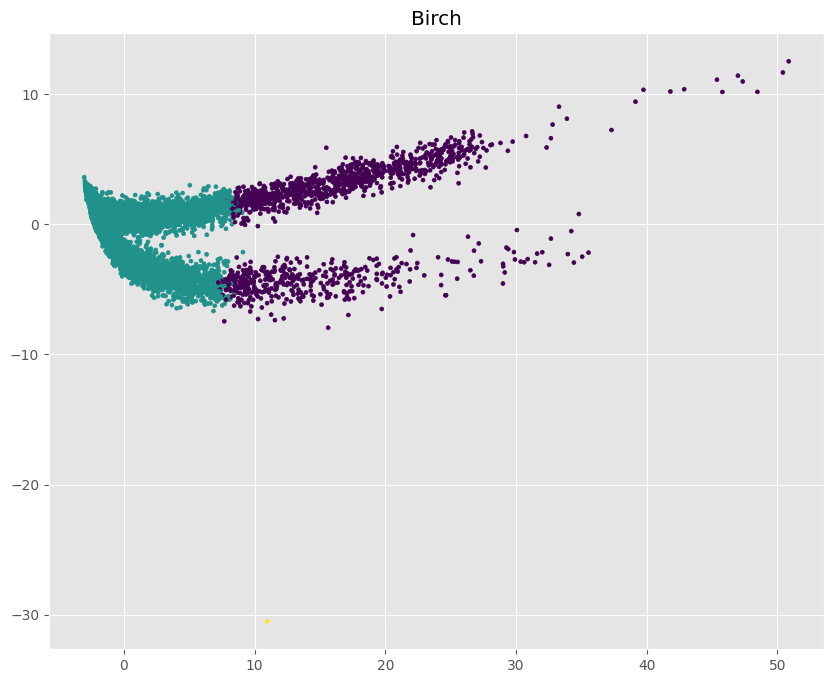

In [ ]:
# ============================================================
# Лучшая модель
# ============================================================

best_model = results.iloc[0]["Model"]

print("Лучшая модель:", best_model)

labels = labels_dict[best_model]

pca2 = PCA(
    n_components=2,
    random_state=42
)

plot = pca2.fit_transform(
    X_pca
)

plt.figure(figsize=(10,8))

plt.scatter(
    plot[:,0],
    plot[:,1],
    c=labels,
    s=8,
    cmap="viridis"
)

plt.title(best_model)

plt.show()

0     1301
1    22177
2        1
Name: count, dtype: int64

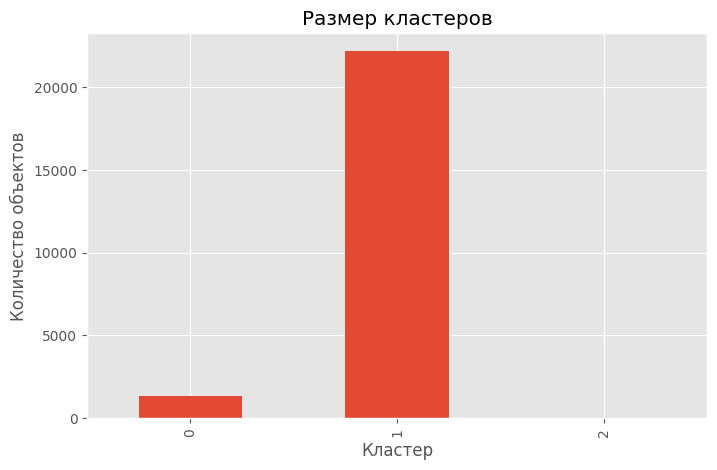

In [ ]:
# ============================================================
# Размер кластеров
# ============================================================

cluster_info = pd.Series(labels).value_counts().sort_index()

display(cluster_info)

cluster_info.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Размер кластеров")

plt.xlabel("Кластер")

plt.ylabel("Количество объектов")

plt.show()

In [ ]:
# ============================================================
# Submission
# ============================================================

submission = pd.DataFrame({

    "index": np.arange(len(labels)),

    "cluster": labels

})

submission.to_csv(
    "submission.csv",
    index=False
)

print(submission.head())

print()

print("submission.csv сохранен")

   index  cluster
0      0        1
1      1        1
2      2        1
3      3        1
4      4        1

submission.csv сохранен


# Заключение

В ходе выполнения работы был проведен полный цикл решения задачи кластеризации сигналов сцинтилляционного детектора.

В процессе исследования были выполнены следующие этапы:

- проведен разведочный анализ данных;
- исследованы статистические характеристики сигналов;
- выполнено извлечение новых информативных признаков;
- проведено снижение размерности методом PCA;
- выполнено сравнение шести алгоритмов кластеризации;
- рассчитаны внутренние метрики качества кластеризации;
- выбрана наиболее эффективная модель;
- сформирован файл submission для соревнования Kaggle.

Полученные результаты показывают, что применение Feature Engineering совместно с современными алгоритмами кластеризации позволяет значительно повысить качество разделения сигналов различных типов.